In [7]:
# Install missing packages into the current Jupyter kernel (use %pip, not pip)
%pip install numpy
%pip install matplotlib
%pip install torch
%pip install transformers

import numpy as np
import matplotlib.pyplot as plt
import torch

from transformers import (
    GPT2Tokenizer, GPT2LMHeadModel,
    BertTokenizer, BertModel,
    logging
)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 25.9 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 24.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 50.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 50.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.6/803.6 kB 33.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# import models
logging.set_verbosity_error()

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2')
#

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 976.42it/s, Materializing param=transformer.wte.weight]             


In [10]:
# Get embeddings matrices
bert_embedding = bert_model.embeddings.word_embeddings.weight.detach().numpy()

gpt_embedding = gpt2_model.transformer.wte.weight.detach().numpy()




In [11]:
seed_word = " ring"
bert_id = bert_tokenizer.encode(seed_word, add_special_tokens=False)
gpt_id = gpt2_tokenizer.encode(seed_word, add_special_tokens=False)

print("BERT ids:", bert_id, "->", [bert_tokenizer.decode([i]) for i in bert_id])
print("GPT2 ids:", gpt_id, "->", [gpt2_tokenizer.decode([i]) for i in gpt_id])

bert_token_id = bert_id[0]
gpt_token_id = gpt_id[0]


BERT ids: [3614] -> ['ring']
GPT2 ids: [5858] -> [' ring']


In [12]:
bert_embedding_vec = bert_embedding[bert_token_id]
gpt_embedding_vec = gpt_embedding[gpt_token_id]


In [13]:
# Calculate the Euclidean distances of each vector from the other vectors in the model's emebdding matrix
bert_dist = np.linalg.norm(bert_embedding - bert_embedding_vec, axis=1)
gpt_dist = np.linalg.norm(gpt_embedding - gpt_embedding_vec, axis=1)

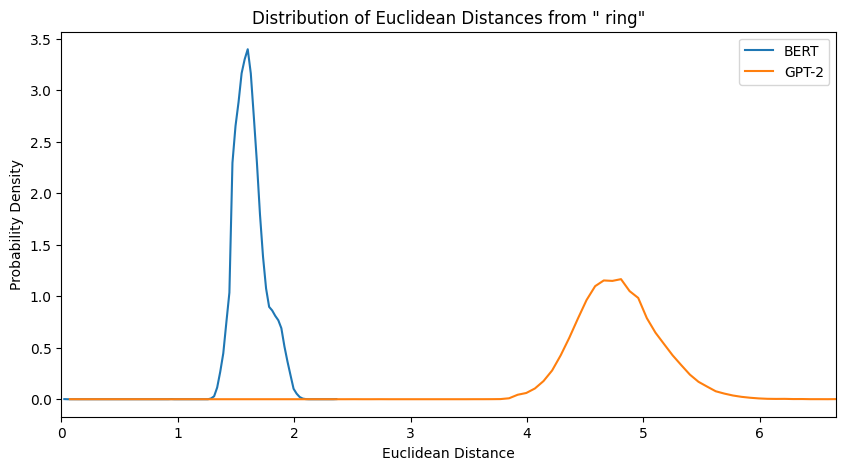

In [14]:
#Visualize the distributions
plt.figure(figsize=(10, 5))
yB, xB = np.histogram(bert_dist, bins=90, density=True)
yG, xG = np.histogram(gpt_dist, bins=90, density=True)

plt.plot(xB[1:], yB, label='BERT')
plt.plot(xG[1:], yG, label='GPT-2')
plt.xlabel('Euclidean Distance')
plt.ylabel('Probability Density')
plt.title(f'Distribution of Euclidean Distances from "{seed_word}"')
plt.gca().set(xlim=[min(xB.min(), xG.min()), max(xB.max(), xG.max())])
plt.legend()
plt.show()


In [15]:
# Calculate top-15 nearest tokens in BERT and GPT2
bert_top_15_idx = np.argsort(bert_dist)[:15]
bert_top_15 = [bert_tokenizer.decode(i) for i in bert_top_15_idx]

gpt_top_15_idx = np.argsort(gpt_dist)[:15]
gpt_top_15 = [gpt2_tokenizer.decode(i) for i in gpt_top_15_idx]

In [16]:
print('***Top 15 nearest tokens to "ring" in BERT****')
print('\n'.join([f'"{bert_top_15[i]:15}" at a distance {bert_dist[bert_top_15_idx[i]]:.4f}' for i in range(15)]))

print('\n***Top 15 nearest tokens to "ring" in GPT****')
print('\n'.join([f'"{gpt_top_15[i]:15}" at a distance {gpt_dist[gpt_top_15_idx[i]]:.4f}' for i in range(15)]))

***Top 15 nearest tokens to "ring" in BERT****
"ring           " at a distance 0.0000
"rings          " at a distance 0.9357
"network        " at a distance 1.2634
"1987           " at a distance 1.2768
"1983           " at a distance 1.2793
"1986           " at a distance 1.2799
"fifth          " at a distance 1.2801
"1955           " at a distance 1.2830
"1985           " at a distance 1.2901
"1974           " at a distance 1.2928
"1984           " at a distance 1.2936
"1975           " at a distance 1.2936
"fourth         " at a distance 1.2949
"seven          " at a distance 1.2962
"six            " at a distance 1.2979

***Top 15 nearest tokens to "ring" in GPT****
" ring          " at a distance 0.0000
" rings         " at a distance 2.5073
" Ring          " at a distance 2.6846
"Ring           " at a distance 3.5389
" rang          " at a distance 3.6220
" Rings         " at a distance 3.6588
" ringing       " at a distance 3.6807
" 11            " at a distance 3.7328
" 8      

In [17]:
print("Top-15 nearest tokens in BERT:")
print('\n'.join([word for word in bert_top_15]))

print("\nTop-15 nearest tokens in GPT-2:")
print('\n'.join([word for word in gpt_top_15]))

Top-15 nearest tokens in BERT:
ring
rings
network
1987
1983
1986
fifth
1955
1985
1974
1984
1975
fourth
seven
six

Top-15 nearest tokens in GPT-2:
 ring
 rings
 Ring
Ring
 rang
 Rings
 ringing
 11
 8
 amulet
 make
 15
 13
 10
 85


In [18]:
# Normalize the vectors and the embedding matrix before calculating the distance
bert_embedding_norm = bert_embedding / np.linalg.norm(bert_embedding, axis=1, keepdims=True)
gpt_embedding_norm = gpt_embedding / np.linalg.norm(gpt_embedding, axis=1, keepdims=True)
bert_embedding_vec_norm = bert_embedding_vec / np.linalg.norm(bert_embedding_vec)
gpt_embedding_vec_norm = gpt_embedding_vec / np.linalg.norm(gpt_embedding_vec)

In [19]:
# Calculate the distances on normalized vectors
bert_dist_norm = np.linalg.norm(bert_embedding_norm - bert_embedding_vec_norm, axis=1)
gpt_dist_norm = np.linalg.norm(gpt_embedding_norm - gpt_embedding_vec_norm, axis=1)

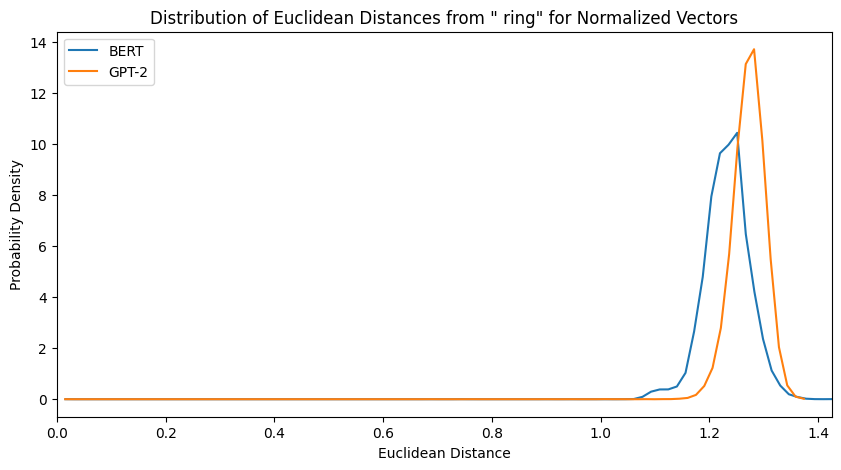

In [20]:
#Visualize the distributions
plt.figure(figsize=(10, 5))
yB, xB = np.histogram(bert_dist_norm, bins=90, density=True)
yG, xG = np.histogram(gpt_dist_norm, bins=90, density=True)

plt.plot(xB[1:], yB, label='BERT')
plt.plot(xG[1:], yG, label='GPT-2')
plt.xlabel('Euclidean Distance')
plt.ylabel('Probability Density')
plt.title(f'Distribution of Euclidean Distances from "{seed_word}" for Normalized Vectors')
plt.gca().set(xlim=[min(xB.min(), xG.min()), max(xB.max(), xG.max())])
plt.legend()
plt.show()


In [21]:
# Calculate top-15 nearest tokens in BERT and GPT2
bert_top_15_norm_idx = np.argsort(bert_dist_norm)[:15]
bert_top_15_norm = [bert_tokenizer.decode(i) for i in bert_top_15_norm_idx]

gpt_top_15_norm_idx = np.argsort(gpt_dist_norm)[:15]
gpt_top_15_norm = [gpt2_tokenizer.decode(i) for i in gpt_top_15_norm_idx]

In [22]:
print('***Top 15 nearest tokens to "ring" in BERT****')
print('\n'.join([f'"{bert_top_15_norm[i]:15}" at a distance {bert_dist_norm[bert_top_15_norm_idx[i]]:.4f}' for i in range(15)]))

print('\n***Top 15 nearest tokens to "ring" in GPT****')
print('\n'.join([f'"{gpt_top_15_norm[i]:15}" at a distance {gpt_dist_norm[gpt_top_15_norm_idx[i]]:.4f}' for i in range(15)]))

***Top 15 nearest tokens to "ring" in BERT****
"ring           " at a distance 0.0000
"rings          " at a distance 0.7386
"ringing        " at a distance 1.0447
"570            " at a distance 1.0524
"282            " at a distance 1.0554
"261            " at a distance 1.0606
"740            " at a distance 1.0609
"186            " at a distance 1.0634
"840            " at a distance 1.0637
"178            " at a distance 1.0644
"41st           " at a distance 1.0655
"284            " at a distance 1.0669
"249            " at a distance 1.0674
"237            " at a distance 1.0674
"rang           " at a distance 1.0678

***Top 15 nearest tokens to "ring" in GPT****
" ring          " at a distance 0.0000
" rings         " at a distance 0.6764
" Ring          " at a distance 0.7589
"Ring           " at a distance 0.8872
" Rings         " at a distance 0.9435
" ringing       " at a distance 0.9981
" amulet        " at a distance 1.0025
" rang          " at a distance 1.0059
"ring    

In [23]:
seed_word = "beauty"
bert_id = bert_tokenizer.encode(seed_word, add_special_tokens=False)
gpt_id = gpt2_tokenizer.encode(seed_word, add_special_tokens=False)

print("BERT ids:", bert_id, "->", [bert_tokenizer.decode([i]) for i in bert_id])
print("GPT2 ids:", gpt_id, "->", [gpt2_tokenizer.decode([i]) for i in gpt_id])

bert_token_id = bert_id[0]
gpt_token_id = gpt_id[0]


BERT ids: [5053] -> ['beauty']
GPT2 ids: [40544, 88] -> ['beaut', 'y']


In [24]:
bert_embedding_vec = bert_embedding[bert_token_id].mean(axis=0)
gpt_embedding_vec = gpt_embedding[gpt_token_id].mean(axis=0)


In [25]:
# Calculate the Euclidean distances of each vector from the other vectors in the model's emebdding matrix
bert_dist = np.linalg.norm(bert_embedding - bert_embedding_vec, axis=1)
gpt_dist = np.linalg.norm(gpt_embedding - gpt_embedding_vec, axis=1)

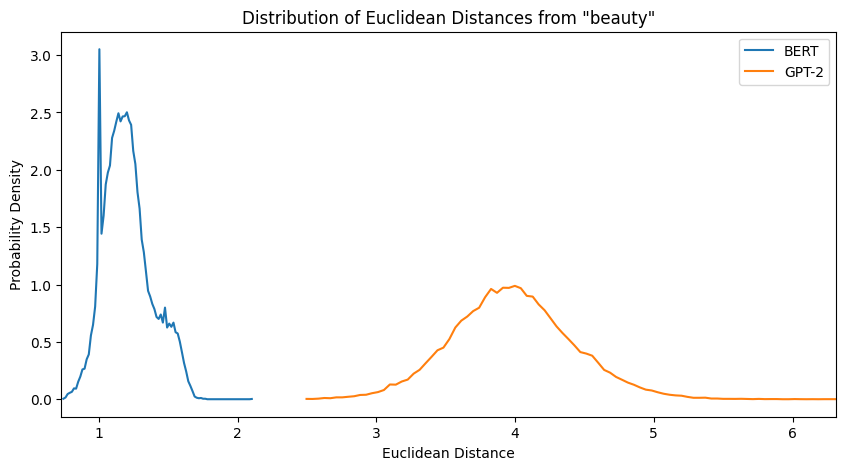

In [26]:
#Visualize the distributions
plt.figure(figsize=(10, 5))
yB, xB = np.histogram(bert_dist, bins=90, density=True)
yG, xG = np.histogram(gpt_dist, bins=90, density=True)

plt.plot(xB[1:], yB, label='BERT')
plt.plot(xG[1:], yG, label='GPT-2')
plt.xlabel('Euclidean Distance')
plt.ylabel('Probability Density')
plt.title(f'Distribution of Euclidean Distances from "{seed_word}"')
plt.gca().set(xlim=[min(xB.min(), xG.min()), max(xB.max(), xG.max())])
plt.legend()
plt.show()


In [27]:
# Calculate top-15 nearest tokens in BERT and GPT2
bert_top_15_idx = np.argsort(bert_dist)[:15]
bert_top_15 = [bert_tokenizer.decode(i) for i in bert_top_15_idx]

gpt_top_15_idx = np.argsort(gpt_dist)[:15]
gpt_top_15 = [gpt2_tokenizer.decode(i) for i in gpt_top_15_idx]

In [28]:
print('***Top 15 nearest tokens to "beauty" in BERT****')
print('\n'.join([f'"{bert_top_15[i]:15}" at a distance {bert_dist[bert_top_15_idx[i]]:.4f}' for i in range(15)]))

print('\n***Top 15 nearest tokens to "beauty" in GPT****')
print('\n'.join([f'"{gpt_top_15[i]:15}" at a distance {gpt_dist[gpt_top_15_idx[i]]:.4f}' for i in range(15)]))

***Top 15 nearest tokens to "beauty" in BERT****
"john           " at a distance 0.7291
"william        " at a distance 0.7421
"1986           " at a distance 0.7540
"1970           " at a distance 0.7551
"the            " at a distance 0.7556
"1980           " at a distance 0.7567
"1982           " at a distance 0.7571
"1995           " at a distance 0.7588
"1969           " at a distance 0.7589
"1993           " at a distance 0.7605
"1985           " at a distance 0.7607
"seven          " at a distance 0.7623
"james          " at a distance 0.7624
"1968           " at a distance 0.7626
"1984           " at a distance 0.7629

***Top 15 nearest tokens to "beauty" in GPT****
" at            " at a distance 2.4540
" in            " at a distance 2.4650
" on            " at a distance 2.4730
" an            " at a distance 2.4741
" for           " at a distance 2.4865
" as            " at a distance 2.4904
" that          " at a distance 2.5077
" 10            " at a distance 2.5192
" to 

In [29]:
print("Top-15 nearest tokens in BERT:")
print('\n'.join([word for word in bert_top_15]))

print("\nTop-15 nearest tokens in GPT-2:")
print('\n'.join([word for word in gpt_top_15]))

Top-15 nearest tokens in BERT:
john
william
1986
1970
the
1980
1982
1995
1969
1993
1985
seven
james
1968
1984

Top-15 nearest tokens in GPT-2:
 at
 in
 on
 an
 for
 as
 that
 10
 to
 15
 12
 by
 5
 8
 In


In [30]:
# Normalize the vectors and the embedding matrix before calculating the distance
bert_embedding_norm = bert_embedding / np.linalg.norm(bert_embedding, axis=1, keepdims=True)
gpt_embedding_norm = gpt_embedding / np.linalg.norm(gpt_embedding, axis=1, keepdims=True)
bert_embedding_vec_norm = bert_embedding_vec / np.linalg.norm(bert_embedding_vec)
gpt_embedding_vec_norm = gpt_embedding_vec / np.linalg.norm(gpt_embedding_vec)

In [31]:
# Calculate the distances on normalized vectors
bert_dist_norm = np.linalg.norm(bert_embedding_norm - bert_embedding_vec_norm, axis=1)
gpt_dist_norm = np.linalg.norm(gpt_embedding_norm - gpt_embedding_vec_norm, axis=1)

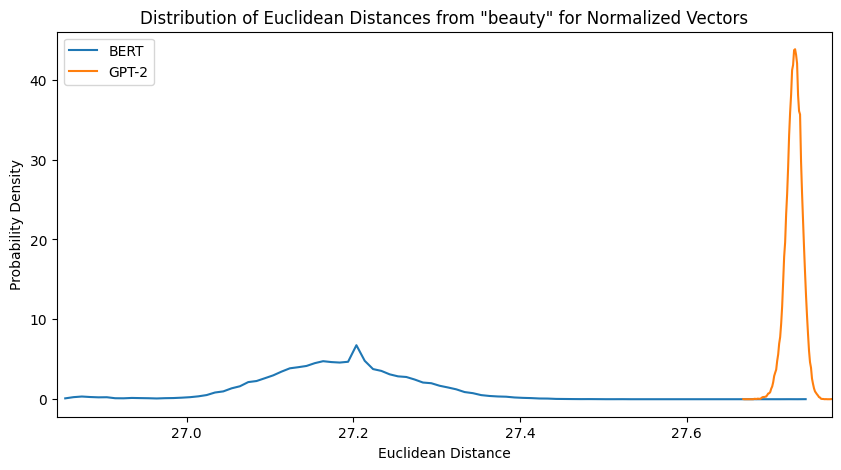

In [32]:
#Visualize the distributions
plt.figure(figsize=(10, 5))
yB, xB = np.histogram(bert_dist_norm, bins=90, density=True)
yG, xG = np.histogram(gpt_dist_norm, bins=90, density=True)

plt.plot(xB[1:], yB, label='BERT')
plt.plot(xG[1:], yG, label='GPT-2')
plt.xlabel('Euclidean Distance')
plt.ylabel('Probability Density')
plt.title(f'Distribution of Euclidean Distances from "{seed_word}" for Normalized Vectors')
plt.gca().set(xlim=[min(xB.min(), xG.min()), max(xB.max(), xG.max())])
plt.legend()
plt.show()


In [33]:
# Calculate top-15 nearest tokens in BERT and GPT2
bert_top_15_norm_idx = np.argsort(bert_dist_norm)[:15]
bert_top_15_norm = [bert_tokenizer.decode(i) for i in bert_top_15_norm_idx]

gpt_top_15_norm_idx = np.argsort(gpt_dist_norm)[:15]
gpt_top_15_norm = [gpt2_tokenizer.decode(i) for i in gpt_top_15_norm_idx]

In [34]:
print('***Top 15 nearest tokens to "ring" in BERT****')
print('\n'.join([f'"{bert_top_15_norm[i]:15}" at a distance {bert_dist_norm[bert_top_15_norm_idx[i]]:.4f}' for i in range(15)]))

print('\n***Top 15 nearest tokens to "ring" in GPT****')
print('\n'.join([f'"{gpt_top_15_norm[i]:15}" at a distance {gpt_dist_norm[gpt_top_15_norm_idx[i]]:.4f}' for i in range(15)]))

***Top 15 nearest tokens to "ring" in BERT****
"1738           " at a distance 26.8440
"229            " at a distance 26.8451
"272            " at a distance 26.8456
"274            " at a distance 26.8464
"324            " at a distance 26.8469
"1729           " at a distance 26.8473
"259            " at a distance 26.8480
"268            " at a distance 26.8486
"244            " at a distance 26.8488
"257            " at a distance 26.8489
"276            " at a distance 26.8496
"321            " at a distance 26.8498
"341            " at a distance 26.8499
"306            " at a distance 26.8505
"307            " at a distance 26.8506

***Top 15 nearest tokens to "ring" in GPT****
"elsius         " at a distance 27.6670
"advertisement  " at a distance 27.6805
"oğ             " at a distance 27.6812
"ohydrate       " at a distance 27.6813
"enzie          " at a distance 27.6816
"omething       " at a distance 27.6821
" Skydragon     " at a distance 27.6824
"ikarp          " at a dis